In [ ]:
#opcional (instala pandas seaborn matplotlib scikit-learn numpy)
%pip install -r requirements.txt

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# EDA:

Cargamos y visualizamos el dataset.

In [56]:
df = pd.read_csv('./content/uber_fares.csv')
df

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:44:41,2.53,2012-10-28 10:44:41 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:13:35,6.55,2014-03-14 01:13:35 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:41:54,31.56,2009-06-29 00:41:54 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:53:55,15.35,2015-05-20 14:53:55 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


Corroboramos la existencia de nulos y observamos el porcentaje respecto al total para decidir que hacer con ellos.

In [58]:
df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / df.shape[0]) * 100
porcentaje_nulos

key                  0.0000
date                 0.0000
fare_amount          0.0000
pickup_datetime      0.0000
pickup_longitude     0.0000
pickup_latitude      0.0000
dropoff_longitude    0.0005
dropoff_latitude     0.0005
passenger_count      0.0000
dtype: float64

Dado que los nulos encontrados en las variables "dropoff_longitude" y "dropoff_latitude" equivalen a un 0.0005% de los datos del dataset, decidimos eliminar sus filas correspondientes para simplificar el preprocesamiento sin afectar el análisis.

In [59]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                199999 non-null  int64  
 1   date               199999 non-null  str    
 2   fare_amount        199999 non-null  float64
 3   pickup_datetime    199999 non-null  str    
 4   pickup_longitude   199999 non-null  float64
 5   pickup_latitude    199999 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    199999 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 15.3 MB


También detectamos que tanto la variable "pickup_datetime" y "date" son de tipo Object, para una mejor manipulacion de datos las transformamos en tipo datetime.

In [60]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199999 non-null  int64              
 1   date               199999 non-null  datetime64[us]     
 2   fare_amount        199999 non-null  float64            
 3   pickup_datetime    199999 non-null  datetime64[us, UTC]
 4   pickup_longitude   199999 non-null  float64            
 5   pickup_latitude    199999 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    199999 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(2)
memory usage: 15.3 MB


Observamos que lo único en lo que difieren los datos de la columna "pickup_datetime" y "date" es en que una muestra la zona horaria. Fuera de eso "date" seria redundante por lo que vamos a comprobar si todas las fechas son iguales y en caso de serlo podriamos eliminar la columna "date".

In [61]:
(df['date'].dt.date == df['pickup_datetime'].dt.date).value_counts()

True    199999
Name: count, dtype: int64

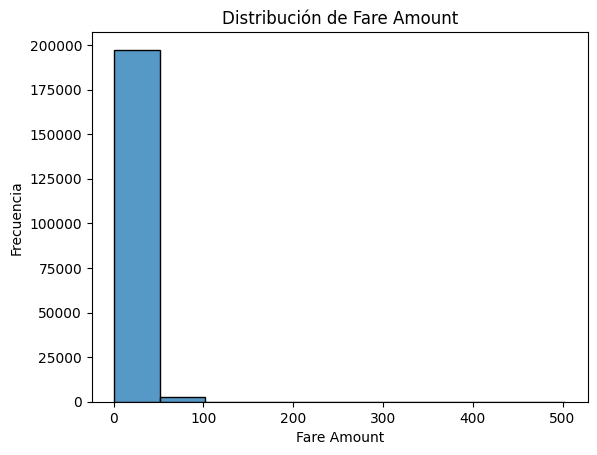

In [63]:
#visualizacion de fare_amount (capaz convenga visualizar otras variables)
sns.histplot(df['fare_amount'], bins=10)
plt.title('Distribución de Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Frecuencia')
plt.show()

Notamos que hay valores atípicos en las tarifas, como 0 o valores exageradamente altos, por lo que conviene eliminarlos 

In [ ]:
#eliminamos los valores atípicos
# Usámos el método de los cuartiles, marcamos como outliers los valores superiores a Q3 + 1,5 × RI o inferiores a Q1 - 1,5 × RI
y = df['fare_amount']

Q1 = y.quantile(0.25) # cuantil 0.25 (busca el valor donde la probabilidad acumulada es del 25%)
Q3 = y.quantile(0.75) # cuantil 0.75 ('' el 75% de las tarifas son menores a este valor)
RI = Q3 - Q1       # rango intercuartílico

limite_inf = Q1 - 1.5 * RI 
limite_sup = Q3 + 1.5 * RI

#corta por encima y por debajo de los límites
df = df[(y >= limite_inf) & (y <= limite_sup)]
df.info()

<class 'pandas.DataFrame'>
Index: 175867 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                175867 non-null  int64              
 1   date               175867 non-null  datetime64[us]     
 2   fare_amount        175867 non-null  float64            
 3   pickup_datetime    175867 non-null  datetime64[us, UTC]
 4   pickup_longitude   175867 non-null  float64            
 5   pickup_latitude    175867 non-null  float64            
 6   dropoff_longitude  175867 non-null  float64            
 7   dropoff_latitude   175867 non-null  float64            
 8   passenger_count    175867 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(2)
memory usage: 13.4 MB


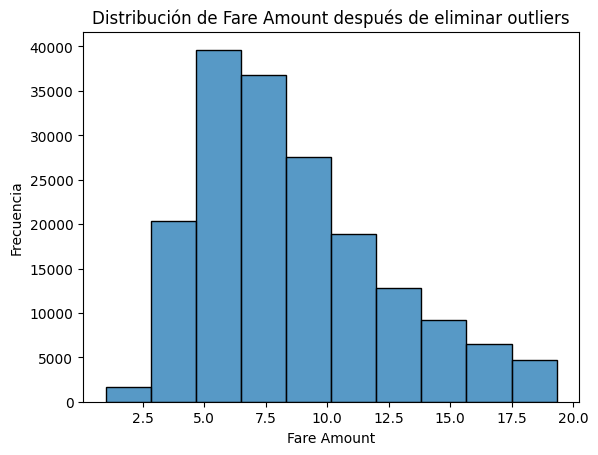

In [64]:
#visualizacion de fare_amount luego de eliminar outliers
sns.histplot(y, bins=10)
plt.title('Distribución de Fare Amount después de eliminar outliers')
plt.xlabel('Fare Amount')
plt.ylabel('Frecuencia')
plt.show()

Vemos que ahora no aparecen valores atípicos y que los precios de las tarifas son razonables, aproximadamente entre 2.5 y 17.5 (asumo que las tarifas están en dólares)